<a href="https://colab.research.google.com/github/me542L/Intelligent-Plant-Disease-Detector-and-Treatment-Recommendation-System/blob/main/Plant_Disease_Detector_and_Treatment_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install gdown

import gdown


file_id = "1NQdorDlZbZcnFBp-Lb7tttDwnhEqe6qz"


gdown.download(f"https://drive.google.com/uc?id={file_id}", "dataset.zip", quiet=False)


!unzip dataset.zip -d /content/dataset


!ls /content/dataset

Downloading...
From: https://drive.google.com/uc?id=1NQdorDlZbZcnFBp-Lb7tttDwnhEqe6qz
To: /content/dataset.zip
100%|██████████| 13.0M/13.0M [00:00<00:00, 13.4MB/s]


Archive:  dataset.zip
  inflating: /content/dataset/annotated_apple_leaf_disease/train/annots/1.xml  
  inflating: /content/dataset/annotated_apple_leaf_disease/train/annots/10.xml  
  inflating: /content/dataset/annotated_apple_leaf_disease/train/annots/100.xml  
  inflating: /content/dataset/annotated_apple_leaf_disease/train/annots/101.xml  
  inflating: /content/dataset/annotated_apple_leaf_disease/train/annots/102.xml  
  inflating: /content/dataset/annotated_apple_leaf_disease/train/annots/103.xml  
  inflating: /content/dataset/annotated_apple_leaf_disease/train/annots/104.xml  
  inflating: /content/dataset/annotated_apple_leaf_disease/train/annots/105.xml  
  inflating: /content/dataset/annotated_apple_leaf_disease/train/annots/106.xml  
  inflating: /content/dataset/annotated_apple_leaf_disease/train/annots/107.xml  
  inflating: /content/dataset/annotated_apple_leaf_disease/train/annots/108.xml  
  inflating: /content/dataset/annotated_apple_leaf_disease/train/annots/109.xml

In [ ]:
import os
import xml.etree.ElementTree as ET
from pathlib import Path


BASE_DIR = Path("/content/dataset/annotated_apple_leaf_disease")
sets = ["train", "valid"]
classes = ["Apple Scab", "Black Rot", "Cedar Apple Rust"]

for dataset in sets:
    img_dir = BASE_DIR / dataset / "images"
    ann_dir = BASE_DIR / dataset / "annots"
    label_dir = BASE_DIR / dataset / "labels"

    os.makedirs(label_dir, exist_ok=True)

    for xml_file in os.listdir(ann_dir):
        if not xml_file.endswith(".xml"):
            continue

        xml_path = ann_dir / xml_file
        tree = ET.parse(xml_path)
        root = tree.getroot()

        image_name = root.find("filename").text
        txt_name = os.path.splitext(image_name)[0] + ".txt"
        txt_path = label_dir / txt_name

        size = root.find("size")
        w = int(size.find("width").text)
        h = int(size.find("height").text)

        lines = []
        for obj in root.findall("object"):
            cls = obj.find("name").text.strip()
            if cls not in classes:
                continue
            cls_id = classes.index(cls)

            xmlbox = obj.find("bndbox")
            xmin = float(xmlbox.find("xmin").text)
            ymin = float(xmlbox.find("ymin").text)
            xmax = float(xmlbox.find("xmax").text)
            ymax = float(xmlbox.find("ymax").text)


            x_center = ((xmin + xmax) / 2) / w
            y_center = ((ymin + ymax) / 2) / h
            width = (xmax - xmin) / w
            height = (ymax - ymin) / h

            lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

        with open(txt_path, "w") as f:
            f.write("\n".join(lines))

print("✅ Conversion complete! YOLO-format labels saved under each dataset's 'labels/' folder.")


✅ Conversion complete! YOLO-format labels saved under each dataset's 'labels/' folder.


In [ ]:
!pip install ultralytics opencv-python matplotlib roboflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 136.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
import yaml

data_config = {
    'train': '/content/dataset/annotated_apple_leaf_disease/train/images',
    'val': '/content/dataset/annotated_apple_leaf_disease/valid/images',
    'nc': 3,
    'names': ['Apple Scab', 'Black Rot', 'Cedar Apple Rust']
}

with open('/content/apple_leaf.yaml', 'w') as f:
    yaml.dump(data_config, f)

print(open('/content/apple_leaf.yaml').read())


names:
- Apple Scab
- Black Rot
- Cedar Apple Rust
nc: 3
train: /content/dataset/annotated_apple_leaf_disease/train/images
val: /content/dataset/annotated_apple_leaf_disease/valid/images



In [ ]:
from ultralytics import YOLO


model = YOLO('yolov8n.pt')


model.train(
    data='/content/apple_leaf.yaml',
    epochs=11,
    imgsz=640,
    batch=16,
    name='apple_leaf_disease_detector'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/apple_leaf.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=11, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e9c31787800>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
metrics = model.val()
print(metrics)


Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 739.4±316.1 MB/s, size: 14.1 KB)
val: Scanning /content/dataset/annotated_apple_leaf_disease/valid/labels.cache... 170 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 170/170 342.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.6it/s 4.3s
                   all        170       1791       0.68      0.638      0.678      0.255
            Apple Scab         60        586      0.608      0.529      0.563      0.218
             Black Rot         60        362      0.675      0.768      0.766      0.269
      Cedar Apple Rust         50        843      0.758      0.618      0.704      0.279
Speed: 3.9ms preprocess, 5.3ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/r


image 1/1 /content/dataset/annotated_apple_leaf_disease/valid/images/514.JPG: 640x640 35 Cedar Apple Rusts, 8.3ms
Speed: 2.2ms preprocess, 8.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


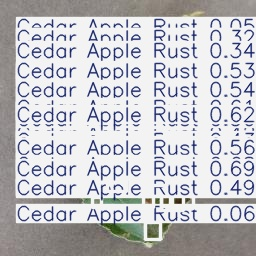


🩺 **Detection Summary**
Cedar Apple Rust: 9.28% infection
💊 Treatment Suggestion → 🟢 Mild (Level 1) - Light preventive spray


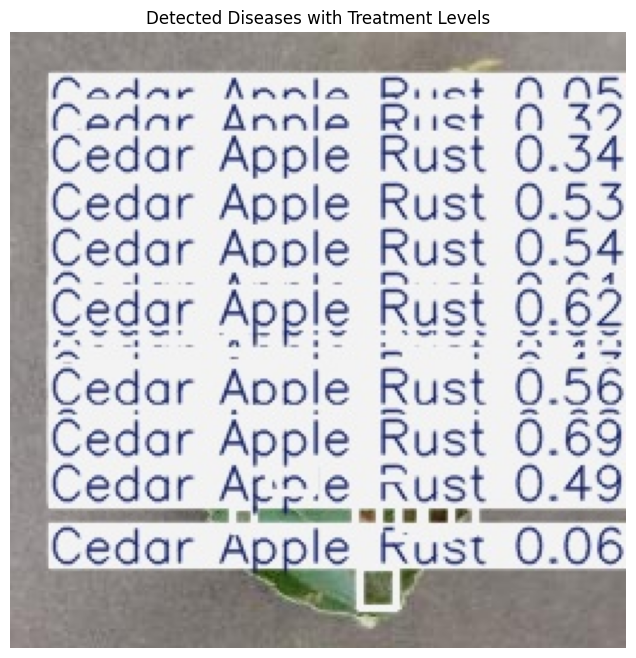

In [ ]:

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import IPython.display as display


model = YOLO("/content/runs/detect/apple_leaf_disease_detector/weights/best.pt")


img_path = "/content/dataset/annotated_apple_leaf_disease/valid/images/514.JPG"


results = model.predict(img_path, conf=0.05, iou=0.4)


results[0].save(filename="detection_output.jpg")
display.display(Image.open("detection_output.jpg"))


r = results[0]
img = cv2.imread(img_path)
h, w, _ = img.shape

boxes = r.boxes.xyxy.cpu().numpy()
labels = r.boxes.cls.cpu().numpy()
confs = r.boxes.conf.cpu().numpy()
class_names = model.names

total_area = h * w
disease_areas = {}



for box, cls_id, conf in zip(boxes, labels, confs):
    x1, y1, x2, y2 = box
    area = (x2 - x1) * (y2 - y1)
    disease = class_names[int(cls_id)]
    disease_areas[disease] = disease_areas.get(disease, 0) + area

# Compute infection percentage
infection_percentages = {d: (a / total_area) * 100 for d, a in disease_areas.items()}
sorted_infections = sorted(infection_percentages.items(), key=lambda x: x[1], reverse=True)


print("\n **Detection Summary**")
if not sorted_infections:
    print("No infection detected.")
else:
    for disease, perc in sorted_infections:
        if perc <= 0:
            continue
        print(f"{disease}: {perc:.2f}% infection")

        # Treatment suggestion logic
        if perc < 1:
            level = "🟢 Very Early Stage - Monitor leaf, preventive spray only"
        elif perc < 10:
            level = "🟢 Mild (Level 1) - Light preventive spray"
        elif perc < 30:
            level = "🟡 Moderate (Level 2) - Apply fungicide lightly"
        elif perc < 60:
            level = "🟠 Severe (Level 3) - Immediate strong treatment"
        else:
            level = "🔴 Critical (Level 4) - Heavy pesticide recommended"

        print(f"💊 Treatment Suggestion → {level}")



img_rgb = cv2.cvtColor(cv2.imread("detection_output.jpg"), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Detected Diseases with Treatment Levels")
plt.show()



In [ ]:
from google.colab import files

# Zip and download the trained YOLO model
!zip -r apple_disease_model.zip /content/runs/detect/apple_leaf_disease_detector/weights/best.pt
files.download("apple_disease_model.zip")


  adding: content/runs/detect/apple_leaf_disease_detector/weights/best.pt (deflated 10%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>